In [106]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt


In [107]:
data = pd.read_csv("9ef84268-d588-465a-a308-a864a43d0070.csv")
data

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
0,Uttar Pradesh,Maharajganj,Anandnagar APMC,Wheat,Dara,FAQ,26/02/2026,2425,2625,2525.0
1,Gujarat,Ahmedabad,Sanad APMC,Wheat,Sharbati,FAQ,26/02/2026,2575,2575,2575.0
2,West Bengal,Darjeeling,Siliguri APMC,Rice,Fine(Basmati),FAQ,26/02/2026,4700,4900,4800.0
3,Tamil Nadu,Namakkal,Tiruchengode APMC,Maize,Deshi Red,Local,26/02/2026,2500,3000,2750.0
4,Tamil Nadu,Erode,Gobichettipalayam(Uzhavar Sandhai ) APMC,Maize,Deshi Red,Local,26/02/2026,3000,3500,3250.0
...,...,...,...,...,...,...,...,...,...,...
5584,Tamil Nadu,Kancheepuram,Padappai(Uzhavar Sandhai ) APMC,Mint(Pudina),Mint(Pudina),Local,26/02/2026,2000,3000,2500.0
5585,Tamil Nadu,Thiruvannamalai,Tiruvannamalai(Uzhavar Sandhai ) APMC,Rose(Local),Rose (Local),Local,26/02/2026,7000,8000,7500.0
5586,Tamil Nadu,Krishnagiri,Krishnagiri(Uzhavar Sandhai ) APMC,Rose(Local),Rose (Local),Local,26/02/2026,12000,14000,13000.0
5587,Tamil Nadu,Namakkal,Rasipuram(Uzhavar Sandhai ) APMC,Rose(Local),Rose (Local),Local,26/02/2026,12000,13000,12500.0


In [108]:
data.columns = data.columns.str.strip()


print("Initial Dataset Shape:", data.shape)
data

Initial Dataset Shape: (5589, 10)


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
0,Uttar Pradesh,Maharajganj,Anandnagar APMC,Wheat,Dara,FAQ,26/02/2026,2425,2625,2525.0
1,Gujarat,Ahmedabad,Sanad APMC,Wheat,Sharbati,FAQ,26/02/2026,2575,2575,2575.0
2,West Bengal,Darjeeling,Siliguri APMC,Rice,Fine(Basmati),FAQ,26/02/2026,4700,4900,4800.0
3,Tamil Nadu,Namakkal,Tiruchengode APMC,Maize,Deshi Red,Local,26/02/2026,2500,3000,2750.0
4,Tamil Nadu,Erode,Gobichettipalayam(Uzhavar Sandhai ) APMC,Maize,Deshi Red,Local,26/02/2026,3000,3500,3250.0
...,...,...,...,...,...,...,...,...,...,...
5584,Tamil Nadu,Kancheepuram,Padappai(Uzhavar Sandhai ) APMC,Mint(Pudina),Mint(Pudina),Local,26/02/2026,2000,3000,2500.0
5585,Tamil Nadu,Thiruvannamalai,Tiruvannamalai(Uzhavar Sandhai ) APMC,Rose(Local),Rose (Local),Local,26/02/2026,7000,8000,7500.0
5586,Tamil Nadu,Krishnagiri,Krishnagiri(Uzhavar Sandhai ) APMC,Rose(Local),Rose (Local),Local,26/02/2026,12000,14000,13000.0
5587,Tamil Nadu,Namakkal,Rasipuram(Uzhavar Sandhai ) APMC,Rose(Local),Rose (Local),Local,26/02/2026,12000,13000,12500.0


In [109]:
string_cols = ["State","District","Market","Commodity","Variety","Grade"]

for col in string_cols:
    data[col] = (
        data[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

farmer_district = farmer_info["District"].strip().lower()

In [110]:

data = data[data["State"].str.contains("tamil", na=False)]

print("After Tamil Nadu Filter:", data.shape)

if len(data) == 0:
    raise ValueError("No Tamil Nadu data found.")


After Tamil Nadu Filter: (4594, 10)


In [111]:

farmer_db = pd.DataFrame({
    "Farmer_ID": [101, 102],
    "Name": ["Ravi", "Kumar"],
    "Mobile": ["9876543210", "9123456780"],
    "District": ["thiruvannamalai", "erode"]
})

In [112]:
# Simulate login
logged_in_farmer_id = 101

farmer_info = farmer_db[
    farmer_db["Farmer_ID"] == logged_in_farmer_id
].iloc[0]

farmer_district = farmer_info["District"].strip().lower()

print("Farmer District:", farmer_district)

Farmer District: thiruvannamalai


In [113]:

district_data = data[
    data["District"] == farmer_district
]

print("Rows in Farmer District:", len(district_data))

if len(district_data) == 0:
    raise ValueError("No data available for this farmer district.")


Rows in Farmer District: 172


In [114]:
market_counts = (
    district_data
    .groupby("Market")
    .size()
    .sort_values(ascending=False)
)

nearest_markets = market_counts.head(3).index.tolist()

print("Selected Markets:", nearest_markets)

if len(nearest_markets) == 0:
    raise ValueError("No markets found in this district.")

Selected Markets: ['tiruvannamalai(uzhavar sandhai ) apmc', 'chengam(uzhavar sandhai ) apmc', 'cheyyar(uzhavar sandhai ) apmc']


In [123]:

district_data["Arrival_Date"] = pd.to_datetime(
    district_data["Arrival_Date"],
    errors="coerce",
    dayfirst=True
)

district_data = district_data.dropna(subset=["Arrival_Date"])

# SORT PROPERLY (VERY IMPORTANT)
district_data = district_data.sort_values(
    ["Market", "Commodity", "Arrival_Date"]
)


In [125]:

district_data["Arrival_Date"] = pd.to_datetime(
    district_data["Arrival_Date"],
    errors="coerce",
    dayfirst=True
)

district_data = district_data.dropna(subset=["Arrival_Date"])

district_data["day"] = district_data["Arrival_Date"].dt.day
district_data["month"] = district_data["Arrival_Date"].dt.month
district_data["weekday"] = district_data["Arrival_Date"].dt.weekday

district_data["lag_7"] = (
    district_data
    .groupby(["Market","Commodity"])["Modal_x0020_Price"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

district_data["trend"] = (
    district_data
    .groupby(["Market", "Commodity"])["Modal_x0020_Price"]
    .transform(lambda x: x.diff())
)

district_data = district_data.dropna(subset=["Modal_x0020_Price"])

In [116]:

data_model = district_data.copy()

encoders = {}

for col in string_cols:
    le = LabelEncoder()
    data_model[col] = le.fit_transform(data_model[col])
    encoders[col] = le

In [128]:
features = [
    "State","District","Market",
    "Commodity","Variety","Grade",
    "day","month","weekday","lag_7"
]

X = data_model[features]
y = data_model["Modal_x0020_Price"]

if len(X) < 20:
    raise ValueError("Not enough data to train model.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [129]:

farmer_db = pd.DataFrame({
    "Farmer_ID": [101, 102, 103],
    "Name": ["Ravi", "Kumar", "Suresh"],
    "Mobile": ["9876543210", "9123456780", "9988776655"],
    "District": ["thiruvannamalai", "erode", "salem"]
})

# Simulate login
logged_in_farmer_id = 101

farmer_info = farmer_db[
    farmer_db["Farmer_ID"] == logged_in_farmer_id
].iloc[0]

farmer_district = farmer_info["District"].strip().lower()

print("Farmer District:", farmer_district)


Farmer District: thiruvannamalai


In [130]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed ✅")


Model Training Completed ✅


In [131]:
future_date = datetime.now() + timedelta(days=7)

future_day = future_date.day
future_month = future_date.month
future_weekday = future_date.weekday()

results = {}

for market_name in nearest_markets:

    market_encoded = encoders["Market"].transform([market_name])[0]

    market_data = data_model[
        data_model["Market"] == market_encoded
    ].sort_values("Arrival_Date")

    if len(market_data) == 0:
        continue

    latest_row = market_data.iloc[-1]

    input_data = pd.DataFrame([[
        latest_row["State"],
        latest_row["District"],
        latest_row["Market"],
        latest_row["Commodity"],
        latest_row["Variety"],
        latest_row["Grade"],
        future_day,
        future_month,
        future_weekday,
        latest_row["lag_7"],
        latest_row["trend"]
    ]], columns=features)

    predicted_price = model.predict(input_data)[0]

    results[market_name] = {
        "price": predicted_price,
        "features": input_data
    }



KeyError: 'trend'

In [121]:
if len(results) == 0:
    raise ValueError("No predictions generated.")

best_market = max(results, key=lambda x: results[x]["price"])

print("\n===== MANDI RECOMMENDATION =====\n")

for market in results:
    print(f"{market} → ₹{results[market]['price']:.2f}")

print(f"\n✅ BEST MARKET TO SELL: {best_market}")




===== MANDI RECOMMENDATION =====

tiruvannamalai(uzhavar sandhai ) apmc → ₹4149.98
chengam(uzhavar sandhai ) apmc → ₹4149.98
cheyyar(uzhavar sandhai ) apmc → ₹4149.98

✅ BEST MARKET TO SELL: tiruvannamalai(uzhavar sandhai ) apmc


In [122]:
shap_df = pd.DataFrame({
    "Feature": features,
    "Impact": shap_values.values[0]
}).sort_values(by="Impact", ascending=False)

print(shap_df)

     Feature      Impact
2     Market    1.313841
3  Commodity    0.172711
0      State    0.000000
1   District    0.000000
5      Grade    0.000000
6        day    0.000000
7      month    0.000000
8    weekday    0.000000
4    Variety   -2.839796
9      lag_7 -123.518066



Generating SHAP Explanation...



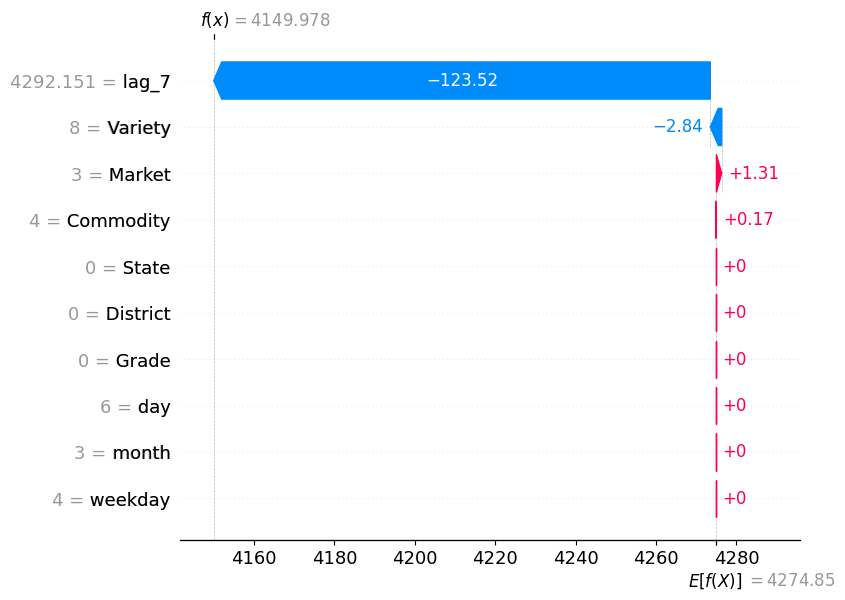

In [105]:
print("\nGenerating SHAP Explanation...\n")

explainer = shap.Explainer(model)
shap_values = explainer(results[best_market]["features"])

shap.plots.waterfall(shap_values[0])
plt.show()
